# **COVID-19 HOSPITALIZATION PREDICTION - MEXICO SISVER DATASEET**
**Machine Learning 2026 — Course Project**

Dataset: [Mexico COVID-19 Clinical Data](https://www.kaggle.com/datasets/marianarfranklin/mexico-covid19-clinical-data) (SISVER, Mexico Secretariat of Health)

Task: Predict whether a patient is hospitalized (binary classification).

**Reproducibility note:** run this notebook top to bottom with no manual edits. Seeds are fixed in the setup cell below.


**Push new version to github:** <br>
git status <br>
git add project_notebook.ipynb <br>
git commit -m "Update notebook with new results" <br>
git push

In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

#random seeds
# random_seed = xy


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fecha_counts = (
    df["FECHA_SINTOMAS"]
    .dropna()
    .astype(str)
)

fecha_counts = pd.to_datetime(fecha_counts, errors="coerce")

result = (
    fecha_counts
    .dt.strftime("%Y-%m-%d")
    .value_counts()
    .sort_index()
    .reset_index()
)

result.columns = ["FECHA_SINTOMAS", "Anzahl"]
print(result)

# counts = df["FECHA_SINTOMAS"].value_counts(dropna=False)
# print(counts.head(30))  # zeige Top 30

# plt.figure(figsize=(12, 6))

# feature = "FECHA_SINTOMAS"

# order = df[feature].value_counts(dropna=False).index
# ax = sns.countplot(data=df, y=feature, order=order, color="steelblue")

# ax.set_title("Verteilung von")
# ax.set_xlabel("Anzahl")
# ax.set_ylabel(feature)

# plt.tight_layout()
# plt.show()

    FECHA_SINTOMAS  Anzahl
0       2020-01-01      22
1       2020-01-02      21
2       2020-01-03      17
3       2020-01-04      20
4       2020-01-05      26
..             ...     ...
149     2020-05-29    1671
150     2020-05-30     786
151     2020-05-31     535
152     2020-06-01     279
153     2020-06-02      34

[154 rows x 2 columns]


## **1. Data Analysis**

Load the dataset CSV which has been downloaded from Kaggle:
https://www.kaggle.com/datasets/marianarfranklin/mexico-covid19-clinical-data

In [18]:
# load the dataset
data_path = "../dataset/mexico_covid19.csv"
download_date = "2026-07-11"

df = pd.read_csv(data_path, sep=None, engine="python", encoding="utf-8")

#fix for encoding issue in "PAIS_NACIONALIDAD"
df["PAIS_NACIONALIDAD"] = df["PAIS_NACIONALIDAD"].str.encode("latin-1", errors="ignore").str.decode("utf-8", errors="ignore")

df

,id,FECHA_ARCHIVO,ID_REGISTRO,ENTIDAD_UM,ENTIDAD_RES,RESULTADO,DELAY,ENTIDAD_REGISTRO,ENTIDAD,ABR_ENT,...,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,9269,2020-04-12,00011f,25,25,2,0,25,Sinaloa,SL,...,2,2,1,2,2,2,99,México,97,97
1,33333,2020-04-12,00014e,14,14,2,0,14,Jalisco,JC,...,2,2,1,2,1,99,99,México,97,2
2,35483,2020-04-12,000153,8,8,1,0,8,Chihuahua,CH,...,2,2,2,2,2,99,99,México,97,2
3,7062,2020-04-12,0001b6,9,15,1,0,9,Ciudad de Mexico,DF,...,2,2,1,2,2,99,99,México,97,97
4,23745,2020-04-12,0001c1,9,9,2,0,9,Ciudad de Mexico,DF,...,2,2,2,2,2,99,99,México,97,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263002,7094887,2020-06-03,1e019c,32,32,1,0,32,Zacatecas,ZS,...,2,2,2,2,2,1,99,México,99,97
263003,7053721,2020-06-03,1e2b05,12,12,1,0,12,Guerrero,GR,...,2,2,1,2,2,99,99,México,99,2
263004,7055429,2020-06-03,1e473f,20,20,1,0,20,Oaxaca,OC,...,2,2,2,1,2,99,99,México,99,2
263005,7043768,2020-06-03,1e6da1,13,13,1,0,13,Hidalgo,HG,...,2,2,2,2,2,2,99,México,99,2


### **1.1 High-level Statistics**
- Number of observations: 263.007 patients
- Missing values per column: MUNICIPIO_RES is missing 6 entries
- Target distribution (class balance): 1 --> 76,36%, 2 --> 23,64%

In [ ]:
#number of observations
df["ORIGEN"].value_counts()

ORIGEN
2    167217
1     95790
Name: count, dtype: int64

In [ ]:
#find missing data
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False) 
missing

MUNICIPIO_RES    6
dtype: int64

In [ ]:
#target distribution
df["TIPO_PACIENTE"].value_counts(normalize=True)

TIPO_PACIENTE
1    0.763622
2    0.236378
Name: proportion, dtype: float64

### **1.2 Leakage Audit**
Important and potentially problematic variables: <br>
| Variable | Available at prediction time? | Included? | Reason |
|---|---|---|---|
| EDAD | Yes | Yes | Baseline information |
| DIABETES | Yes | Yes | Pre-existing condition |
| NEUMONIA | No | No | Downstream of admission |
| INTUBADO | No | No | Downstream of hospitalization |
| RESULTADO | No | No | Shares unobserved cause with the target |
| SECTOR | Yes | No | Describes institution, not patient |

### **1.3 Exploratory Plots**
Plots visualizing first broad characteristics of dataset.

#### **1.3.1 Variable Initialization**

Raw numbers of features

In [ ]:
i = 0                           # increment counter

# variable definition
hosp = 0                        # number of hospitalized patients
outp = 0                        # number of outpatients
npatients = 0                   # number of total patients
male = 0                        # sexo
fem = 0                         # sexo
intub = 0                       # intubado
neumon = 0      # neumonia
emba = 0        # embarazo
diab = 0        # diabetes
epoc = 0        # epoc
asma = 0        # asma
imsup = 0       # inmusupr
hprt = 0        # hipertension
compl = 0       # otra_com
card = 0        # cardiovascular
obs = 0         # obesidad
rcr = 0         # renal_cronica
tbq = 0         # tabaquismo
uci = 0         # intense care unit
resul = 0       # result
#grupo_de_edad = 0
#fallecio = 0

tipo = df['TIPO_PACIENTE'] 

# initialize variables
npatients = len(df)

for i in range(npatients):
   if tipo.iloc[i] == 2:
      hosp = hosp + 1
   elif tipo.iloc[i] == 1:
      outp = outp + 1

assert npatients is not None and npatients > 0, "df ist leer oder nicht geladen"

# sexo: 1 = mujer, 2 = hombre
sexo = df['SEXO']
for i in range(npatients):
    if sexo.iloc[i] == 2:
        male = male + 1
    elif sexo.iloc[i] == 1:
        fem = fem + 1

# intubado: 1 = si
intubado = df['INTUBADO']
for i in range(npatients):
    if intubado.iloc[i] == 1:
        intub = intub + 1

# neumonia: 1 = si
neumonia = df['NEUMONIA']
for i in range(npatients):
    if neumonia.iloc[i] == 1:
        neumon = neumon + 1

# embarazo: 1 = si
embarazo = df['EMBARAZO']
for i in range(npatients):
    if embarazo.iloc[i] == 1:
        emba = emba + 1

# diabetes: 1 = si
diabetes = df['DIABETES']
for i in range(npatients):
    if diabetes.iloc[i] == 1:
        diab = diab + 1

# epoc: 1 = si
epoc_col = df['EPOC']
for i in range(npatients):
    if epoc_col.iloc[i] == 1:
        epoc = epoc + 1

# asma: 1 = si
asma_col = df['ASMA']
for i in range(npatients):
    if asma_col.iloc[i] == 1:
        asma = asma + 1

# inmusupr: 1 = si
inmusupr = df['INMUSUPR']
for i in range(npatients):
    if inmusupr.iloc[i] == 1:
        imsup = imsup + 1

# hipertension: 1 = si
hipertension = df['HIPERTENSION']
for i in range(npatients):
    if hipertension.iloc[i] == 1:
        hprt = hprt + 1

# otra_com: 1 = si
otra_com = df['OTRA_COM']
for i in range(npatients):
    if otra_com.iloc[i] == 1:
        compl = compl + 1

# cardiovascular: 1 = si
cardiovascular = df['CARDIOVASCULAR']
for i in range(npatients):
    if cardiovascular.iloc[i] == 1:
        card = card + 1

# obesidad: 1 = si
obesidad = df['OBESIDAD']
for i in range(npatients):
    if obesidad.iloc[i] == 1:
        obs = obs + 1

# renal_cronica: 1 = si
renal_cronica = df['RENAL_CRONICA']
for i in range(npatients):
    if renal_cronica.iloc[i] == 1:
        rcr = rcr + 1

# tabaquismo: 1 = si
tabaquismo = df['TABAQUISMO']
for i in range(npatients):
    if tabaquismo.iloc[i] == 1:
        tbq = tbq + 1

# intense care unit: 1 = si
intensecare = df['UCI']
for i in range(npatients):
    if intensecare.iloc[i] == 1:
        uci = uci + 1

# test result: 1 = positivo
resultado = df['RESULTADO']
for i in range(npatients):
    if resultado.iloc[i] == 1:
        resul = resul + 1

print(f"male: {male}, female: {fem}")
print(f"intubated: {intub}")
print(f"pneumonia: {neumon}")
print(f"pregnant: {emba}")
print(f"diabetes: {diab}")
print(f"epoc: {epoc}")
print(f"asma: {asma}")
print(f"immunosuppressed: {imsup}")
print(f"hypertension: {hprt}")
print(f"other complication: {compl}")
print(f"cardiovascular: {card}")
print(f"obesity: {obs}")
print(f"chronic renal: {rcr}")
print(f"smoking: {tbq}")
print(f"intense care unit: {uci}")
print(f"resultado positivo: {resul}")

male: 134313, female: 128694
intubated: 3884
pneumonia: 42652
pregnant: 2064
diabetes: 34010
epoc: 5187
asma: 9519
immunosuppressed: 5053
hypertension: 44236
other complication: 9629
cardiovascular: 6784
obesity: 43758
chronic renal: 5729
smoking: 23729
intense care unit: 4696
resultado positivo: 102659


Amount of features among hospitalized patients

In [ ]:
# variable definition: variables among hospitalied patients
npatients = 0         # total amount of patients
male_hosp = 0        # sexo among hospitalized patients
fem_hosp = 0          # sexo among hospitalized patients
intub_hosp = 0        # intubado among hospitalized patients
neumon_hosp = 0       # neumonia among hospitalized patients
emba_hosp = 0         # embarazo among hospitalized patients
diab_hosp = 0         # diabetes among hospitalized patients
epoc_hosp = 0         # epoc among hospitalized patients
asma_hosp = 0         # asma among hospitalized patients
imsup_hosp = 0        # inmusupr among hospitalized patients
hprt_hosp = 0         # hipertension among hospitalized patients
compl_hosp = 0        # otra_com among hospitalized patients
card_hosp = 0         # cardiovascular among hospitalized patients
obs_hosp = 0          # obesidad among hospitalized patients
rcr_hosp = 0          # renal_cronica among hospitalized patients
tbq_hosp = 0          # tabaquismo among hospitalized patients
uci_hosp = 0 
resul_hosp = 0
npatients = len(df)

# sexo: 1 = mujer, 2 = hombre
sexo = df['SEXO']
for i in range(npatients):
    if sexo.iloc[i] == 2 and tipo.iloc[i] == 2:
        male_hosp = male_hosp + 1
    elif sexo.iloc[i] == 1 and tipo.iloc[i] == 2:
        fem_hosp = fem_hosp + 1

# intubado: 1 = si
intubado = df['INTUBADO']
for i in range(npatients):
    if intubado.iloc[i] == 1 and tipo.iloc[i] == 2:
        intub_hosp = intub_hosp + 1

# neumonia: 1 = si
neumonia = df['NEUMONIA']
for i in range(npatients):
    if neumonia.iloc[i] == 1 and tipo.iloc[i] == 2:
        neumon_hosp = neumon_hosp + 1

# embarazo: 1 = si
embarazo = df['EMBARAZO']
for i in range(npatients):
    if embarazo.iloc[i] == 1 and tipo.iloc[i] == 2:
        emba_hosp = emba_hosp + 1

# diabetes: 1 = si
diabetes = df['DIABETES']
for i in range(npatients):
    if diabetes.iloc[i] == 1 and tipo.iloc[i] == 2:
        diab_hosp = diab_hosp + 1

# epoc: 1 = si
epoc_col = df['EPOC']
for i in range(npatients):
    if epoc_col.iloc[i] == 1 and tipo.iloc[i] == 2:
        epoc_hosp = epoc_hosp + 1

# asma: 1 = si
asma_col = df['ASMA']
for i in range(npatients):
    if asma_col.iloc[i] == 1 and tipo.iloc[i] == 2:
        asma_hosp = asma_hosp + 1

# inmusupr: 1 = si
inmusupr = df['INMUSUPR']
for i in range(npatients):
    if inmusupr.iloc[i] == 1 and tipo.iloc[i] == 2:
        imsup_hosp = imsup_hosp + 1

# hipertension: 1 = si
hipertension = df['HIPERTENSION']
for i in range(npatients):
    if hipertension.iloc[i] == 1 and tipo.iloc[i] == 2:
        hprt_hosp = hprt_hosp + 1

# otra_com: 1 = si
otra_com = df['OTRA_COM']
for i in range(npatients):
    if otra_com.iloc[i] == 1 and tipo.iloc[i] == 2:
        compl_hosp = compl_hosp + 1

# cardiovascular: 1 = si
cardiovascular = df['CARDIOVASCULAR']
for i in range(npatients):
    if cardiovascular.iloc[i] == 1 and tipo.iloc[i] == 2:
        card_hosp = card_hosp + 1

# obesidad: 1 = si
obesidad = df['OBESIDAD']
for i in range(npatients):
    if obesidad.iloc[i] == 1 and tipo.iloc[i] == 2:
        obs_hosp = obs_hosp + 1

# renal_cronica: 1 = si
renal_cronica = df['RENAL_CRONICA']
for i in range(npatients):
    if renal_cronica.iloc[i] == 1 and tipo.iloc[i] == 2:
        rcr_hosp = rcr_hosp + 1

# tabaquismo: 1 = si
tabaquismo = df['TABAQUISMO']
for i in range(npatients):
    if tabaquismo.iloc[i] == 1 and tipo.iloc[i] == 2:
        tbq_hosp = tbq_hosp + 1

# intense care unit: 1 = si
intensecare = df['UCI']
for i in range(npatients):
    if intensecare.iloc[i] == 1 and tipo.iloc[i] == 2:
        uci_hosp = uci_hosp + 1

# resultado positivo: 1 = si
resultado = df['RESULTADO']
for i in range(npatients):
    if resultado.iloc[i] == 1 and tipo.iloc[i] == 2:
        resul_hosp = resul_hosp + 1

print(f"male_hosp: {male_hosp}, female_hosp: {fem_hosp}")
print(f"intubated_hosp: {intub_hosp}")
print(f"pneumonia_hosp: {neumon_hosp}")
print(f"pregnant_hosp: {emba_hosp}")
print(f"diabetes_hosp: {diab_hosp}")
print(f"epoc_hosp: {epoc_hosp}")
print(f"asma_hosp: {asma_hosp}")
print(f"immunosuppressed_hosp: {imsup_hosp}")
print(f"hypertension_hosp: {hprt_hosp}")
print(f"other_complication_hosp: {compl_hosp}")
print(f"cardiovascular_hosp: {card_hosp}")
print(f"obesity_hosp: {obs_hosp}")
print(f"chronic_renal_hosp: {rcr_hosp}")
print(f"smoking_hosp: {tbq_hosp}")
print(f"uci_hosp: {uci_hosp}")
print(f"resul_hosp: {resul_hosp}")

male_hosp: 37438, female_hosp: 24731
intubated_hosp: 3884
pneumonia_hosp: 36441
pregnant_hosp: 581
diabetes_hosp: 17738
epoc_hosp: 3254
asma_hosp: 1784
immunosuppressed_hosp: 2774
hypertension_hosp: 20013
other_complication_hosp: 4062
cardiovascular_hosp: 3456
obesity_hosp: 12766
chronic_renal_hosp: 3825
smoking_hosp: 5962
uci_hosp: 4696
resul_hosp: 35285


ratio of feature in case of hospitalizion to total amount of patients in featurue, with no respect to hospitalization or not 

In [ ]:
required_vars = [
    "intub", "intub_hosp", "neumon", "neumon_hosp", "emba", "emba_hosp",
    "diab", "diab_hosp", "epoc", "epoc_hosp", "asma", "asma_hosp",
    "imsup", "imsup_hosp", "hprt", "hprt_hosp", "compl", "compl_hosp",
    "card", "card_hosp", "obs", "obs_hosp", "rcr", "rcr_hosp",
    "tbq", "tbq_hosp", "uci", "uci_hosp"
]

for var in required_vars:
    assert var in dir() and eval(var) != 0, f"{var} ist nicht berechnet oder 0 — vorherige Zellen zuerst ausführen"


male_shr = male_hosp / male
fem_shr = fem_hosp / fem
intub_shr = intub_hosp / intub
neumon_shr = neumon_hosp / neumon
emba_shr = emba_hosp / emba
diab_shr = diab_hosp / diab
epoc_shr = epoc_hosp / epoc
asma_shr = asma_hosp / asma
imsup_shr = imsup_hosp / imsup
hprt_shr = hprt_hosp / hprt
compl_shr = compl_hosp / compl
card_shr = card_hosp / card
obs_shr = obs_hosp / obs
rcr_shr = rcr_hosp / rcr
tbq_shr = tbq_hosp / tbq
uci_shr = uci_hosp/ uci
resul_shr = resul_hosp/ resul

print(f"Hospitalized male / total male: {male_shr:.2%}")
print(f"Hospitalized female / total female: {fem_shr:.2%}")
print(f"Hospitalized intubated / total intubated: {intub_shr:.2%}")
print(f"Hospitalized pneumonia / total pneumonia: {neumon_shr:.2%}")
print(f"Hospitalized pregnant / total pregnant: {emba_shr:.2%}")
print(f"Hospitalized diabetes / total diabetes: {diab_shr:.2%}")
print(f"Hospitalized COPD / total COPD: {epoc_shr:.2%}")
print(f"Hospitalized asthma / total asthma: {asma_shr:.2%}")
print(f"Hospitalized immunosuppressed / total immunosuppressed: {imsup_shr:.2%}")
print(f"Hospitalized hypertension / total hypertension: {hprt_shr:.2%}")
print(f"Hospitalized other comorbidities / total other comorbidities: {compl_shr:.2%}")
print(f"Hospitalized cardiovascular / total cardiovascular: {card_shr:.2%}")
print(f"Hospitalized obesity / total obesity: {obs_shr:.2%}")
print(f"Hospitalized chronic kidney disease / total chronic kidney disease: {rcr_shr:.2%}")
print(f"Hospitalized smokers / total smokers: {tbq_shr:.2%}")
print(f"Hospitalized UCI / total UCI: {uci_shr:.2%}")
print(f"Hospitalized positive resultado / total positive resultaddo: {resul_shr:.2%}")

Hospitalized male / total male: 27.87%
Hospitalized female / total female: 19.22%
Hospitalized intubated / total intubated: 100.00%
Hospitalized pneumonia / total pneumonia: 85.44%
Hospitalized pregnant / total pregnant: 28.15%
Hospitalized diabetes / total diabetes: 52.16%
Hospitalized COPD / total COPD: 62.73%
Hospitalized asthma / total asthma: 18.74%
Hospitalized immunosuppressed / total immunosuppressed: 54.90%
Hospitalized hypertension / total hypertension: 45.24%
Hospitalized other comorbidities / total other comorbidities: 42.19%
Hospitalized cardiovascular / total cardiovascular: 50.94%
Hospitalized obesity / total obesity: 29.17%
Hospitalized chronic kidney disease / total chronic kidney disease: 66.77%
Hospitalized smokers / total smokers: 25.13%
Hospitalized UCI / total UCI: 100.00%
Hospitalized positive resultado / total positive resultaddo: 34.37%


Plots for the following topics:
- understand the prediction task → zeigt dir was?
- Confounder aufdecken → zeigt dir was?
- Datenqualitätsprobleme → zeigt dir was?
- Preprocessing-Entscheidungen motivieren → zeigt dir was?

**Understand the prediction task** <br>

Prediction task: predict whether a patient presenting with COVID-like respiratory symptoms will be hospitalized or treated as an outpatient at the time of initial presentation. <br>

In order to understand this I am interested in following shares: <br>

And also in the correlation of:
- hospitalization and age
- death and age
- death and hospitalization 
- death and no hospitalization? --> rules out death as factor because there is no evidence of the hospital taking into account anybody apart from people dying in their intensive care unit 

ideas: <br> 
- divide time frame into months to see if there is any correlation between months and hospitalization
- new variable, e.g. DIFERENCIA_INGRESO in days = FECHA_INGRESO - FECHA_SINTOMAS
- DIFERENCIA_INGRESO/ hospitalized (ingreso == visita, does not mean the patient has been taken to the hospital, it just refers to the date the patient arrived no matter how)
- DIFERENCIA_INGRESO - FECHA_DEF (date the patient died) = DIFERENCIA_FALLECIMIENTO
- DIFERENCIA_FALLECIMIENTO_INGRESO = FECHA_DEF - FECHA_INGRESO
- DIFERENCIA_FALLECIMIENTO_SINTOMAS = FECHA_DEF - FECHA_SINTOMAS

Share of hospitalization among a selection of features

In [ ]:
#hospitalized/ whole population
#df['TIPO_PACIENTE'] / df.column size
#female/ hospitalized
#intubado/ hospitalized
#neumonia/ hospitalized
#embarazo/ hospitalized
#diabetes/ hospitalized
#epoc/ hospitalized
#asma/ hospitalized
#inmunosuprimido/ hospitalized
#hipertensión/ hospitalized
#otra complicacion/ hospitalized
#cardiovascular/ hospitalized
#obesidad/ hospitalized
#renal_cronica/ hospitalized
#tabaquismo/ hospitalized
#grupo de edad/ hospitalized
#fallecio/ hospitalized


#### **1.3.2 Plots**

**1: Target Distribution: Hospitalization Status** 
<br>
Understand Prediction Task

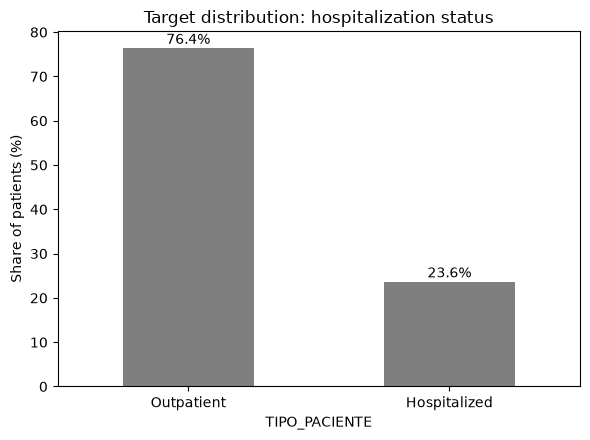

In [ ]:
# plot der verteilung von outpatient und hospitalisierung
pct = df["TIPO_PACIENTE"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4.5))
pct.plot(kind="bar", color="#7F7F7F", ax=ax)
plt.xticks([0, 1], ["Outpatient", "Hospitalized"], rotation=0)
plt.ylabel("Share of patients (%)")
plt.title("Target distribution: hospitalization status")

for i, v in enumerate(pct):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

# 1 ambulant
# 2 hospitalisiert

# 1 positiv
# 2 negativ

**2: Hospitalisation Rate per Resultado Group**<br>
Reveal Potential Confounders

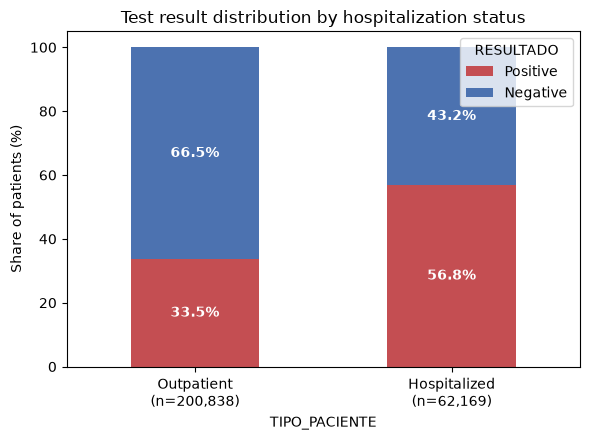

In [ ]:
import matplotlib.pyplot as plt

result_share = df.groupby("TIPO_PACIENTE")["RESULTADO"].value_counts(normalize=True).unstack() * 100
result_share
group_counts = df["TIPO_PACIENTE"].value_counts()
group_counts
fig, ax = plt.subplots(figsize=(6, 4.5))
result_share.plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"], ax=ax, width=0.5)

labels = [
    f"Outpatient\n(n={group_counts[1]:,})",
    f"Hospitalized\n(n={group_counts[2]:,})"
]
ax.set_xticklabels(labels, rotation=0)

for i, tipo in enumerate(result_share.index):
    cum = 0
    for col in result_share.columns:
        val = result_share.loc[tipo, col]
        ax.text(i, cum + val / 2, f"{val:.1f}%", ha="center", va="center",
                color="white", fontweight="bold")
        cum += val

plt.ylabel("Share of patients (%)")
plt.title("Test result distribution by hospitalization status")
plt.legend(["Positive", "Negative"], title="RESULTADO", loc="upper right")
plt.tight_layout()
plt.show()

**3: Preprocessing Evaluation**

HABLA_LENGUA_INDIG     2.671032
ENTIDAD_NAC            4.768314
PAIS_NACIONALIDAD      7.116160
OTRO_CASO             31.601440
EMBARAZO              51.278483
INTUBADO              76.376674
UCI                   76.377435
MIGRANTE              99.582521
PAIS_ORIGEN           99.863502


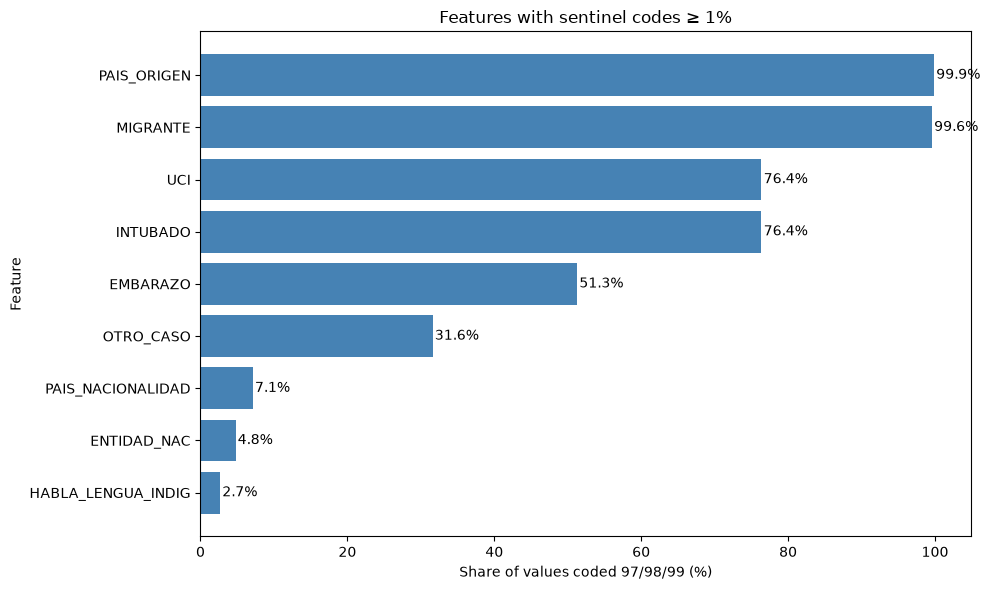

In [ ]:
# 97    NOT APPLICABLE
# 98    IGNORED / UNKNOWN
# 99    NOT SPECIFIED
# 97 = NO APLICA: „trifft nicht zu“ / „nicht anwendbar“.

# 98 = SE IGNORA: „wird ignoriert“ / „wird nicht berücksichtigt“.

# 99 = NO ESPECIFICADO: „nicht spezifiziert“ / „nicht angegeben“

# 97    NOT APPLICABLE
# 98    IGNORED / UNKNOWN
# 99    NOT SPECIFIED

import pandas as pd
import matplotlib.pyplot as plt

sentinel_codes = [97, 98, 99]

pct = {}
for col in df.columns:
    s = df[col]
    if pd.api.types.is_numeric_dtype(s):
        pct[col] = s.isin(sentinel_codes).mean() * 100
    else:
        pct[col] = s.astype(str).str.strip().isin(['97', '98', '99']).mean() * 100

sentinel_pct = pd.Series(pct).sort_values(ascending=True)
sentinel_pct = sentinel_pct[sentinel_pct >= 1]

print(sentinel_pct.to_string())

fig, ax = plt.subplots(figsize=(10, max(6, len(sentinel_pct) * 0.25)))
bars = ax.barh(sentinel_pct.index, sentinel_pct.values, color='steelblue')

for bar, pct_val in zip(bars, sentinel_pct.values):
    label = f'{pct_val:.1f}%'
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center'
    )

ax.set_xlabel('Share of values coded 97/98/99 (%)')
ax.set_ylabel('Feature')
ax.set_title('Features with sentinel codes ≥ 1%')
plt.tight_layout()
plt.show()

In [ ]:
# # plot der verteilung von positiv und negativ in der target verteilung
# import matplotlib.pyplot as plt

# # Anteile je Gruppe berechnen
# result_share = df.groupby("TIPO_PACIENTE")["RESULTADO"].value_counts(normalize=True).unstack() * 100
# group_counts = df["TIPO_PACIENTE"].value_counts()

# fig, ax = plt.subplots(figsize=(7, 6))
# result_share.plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"], ax=ax)

# # x-Achsen-Beschriftung mit Gesamtzahl je Gruppe
# labels = [
#     f"Outpatient\n(n={group_counts[1]:,})",
#     f"Hospitalized\n(n={group_counts[2]:,})"
# ]
# ax.set_xticklabels(labels, rotation=0)

# # Prozentwerte innerhalb der Balken-Segmente anzeigen
# for i, tipo in enumerate(result_share.index):
#     cum = 0
#     for col in result_share.columns:
#         val = result_share.loc[tipo, col]
#         ax.text(i, cum + val / 2, f"{val:.1f}%", ha="center", va="center",
#                 color="white", fontweight="bold")
#         cum += val

# plt.ylabel("Share of patients (%)")
# plt.title("Test result distribution by hospitalization status")
# plt.legend(["Positive", "Negative"], title="RESULTADO", bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.tight_layout()
# plt.show()

**Phi-Koeffizienz testen zwischen RESULTADO und TIPO_PACIENTE**

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

# Kreuztabelle erstellen
contingency = pd.crosstab(df["RESULTADO"], df["TIPO_PACIENTE"])
print(contingency)

# Chi-Quadrat-Test
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Chi2: {chi2:.2f}, p-value: {p_value:.2e}")

# Phi-Koeffizient (= Pearson-Korrelation bei binären Variablen)
n = contingency.sum().sum()
phi = np.sqrt(chi2 / n)
print(f"Phi coefficient: {phi:.4f}")

TIPO_PACIENTE       1      2
RESULTADO                   
1               67374  35285
2              133464  26884
Chi2: 10745.90, p-value: 0.00e+00
Phi coefficient: 0.2021


## **Code Experimenter**

### **Logistic Regression** 

In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import pandas as pd

# Angenommen: df ist dein DataFrame, target ist TIPO_PACIENTE (1 = ambulant, 2 = hospitalisiert)
# Wichtig: Zielvariable ggf. auf 0/1 umkodieren
y = (df['TIPO_PACIENTE'] == 2).astype(int)  # 1 = hospitalisiert, 0 = ambulant

# --- Variante mit RESULTADO ---
features_with = ['EDAD', 'DIABETES', 'OBESIDAD', 'HIPERTENSION', 'RESULTADO']  # Beispiel-Features
X_with = df[features_with]

X_train, X_test, y_train, y_test = train_test_split(
    X_with, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Wahrscheinlichkeit für Klasse 1
auc_with = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC with RESULTADO: {auc_with:.3f}")

# --- Variante ohne RESULTADO ---
features_without = ['EDAD', 'DIABETES', 'OBESIDAD', 'HIPERTENSION']  # gleiche Features, ohne RESULTADO

X_without = df[features_without]
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_without, y, test_size=0.2, random_state=42, stratify=y  # gleicher Seed = gleicher Split!
)

X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train2_scaled, y_train2)

y_pred_proba2 = model2.predict_proba(X_test2_scaled)[:, 1]
auc_without = roc_auc_score(y_test2, y_pred_proba2)
print(f"ROC-AUC without RESULTADO: {auc_without:.3f}")

# ROC-AUC with RESULTADO: 0.734 
# ROC-AUC without RESULTADO: 0.709

ROC-AUC with RESULTADO: 0.734
ROC-AUC without RESULTADO: 0.709


### **Next**

In [ ]:
# next


### **Supplementary Plots**

Durchschnittsalter aller Patienten: 42.59


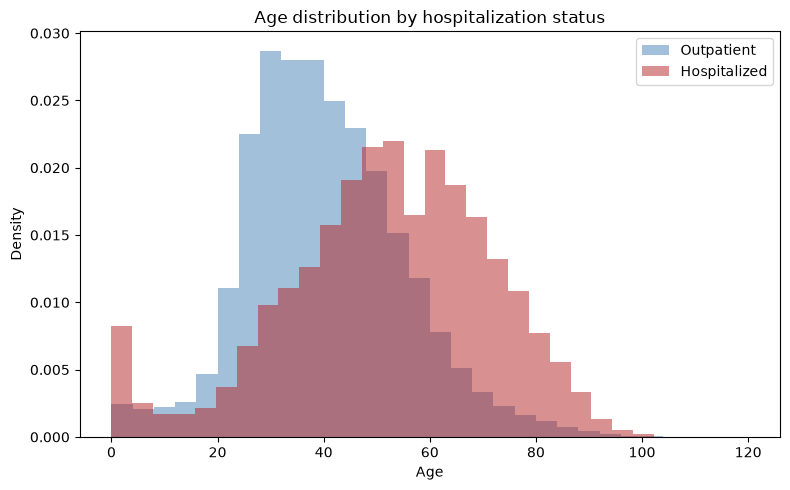

Average age of hospitalized patients: 51.80


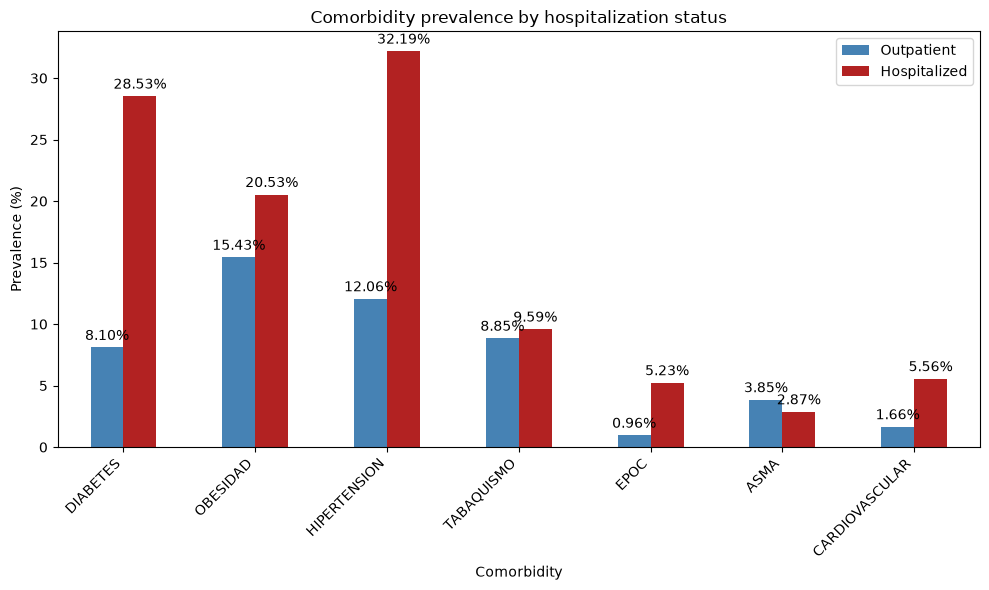

In [ ]:
#verteilungen in den einzelnen gruppen
import pandas as pd
import matplotlib.pyplot as plt

# Durchschnittsalter aller Patienten
avg_age = df['EDAD'].dropna().mean()

print(f"Durchschnittsalter aller Patienten: {avg_age:.2f}")

# --- 1. Age distribution by hospitalization status ---
fig, ax = plt.subplots(figsize=(8, 5))
for status, label, color in [(1, 'Outpatient', 'steelblue'), (2, 'Hospitalized', 'firebrick')]:
    subset = df[df['TIPO_PACIENTE'] == status]['EDAD']
    ax.hist(subset, bins=30, alpha=0.5, density=True, label=label, color=color)

ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Age distribution by hospitalization status')
ax.legend()
plt.tight_layout()
plt.show()

#1.1 mean age among hospitalized
hospitalized_age = df.loc[df['TIPO_PACIENTE'] == 2, 'EDAD'].dropna().mean()
print(f"Average age of hospitalized patients: {hospitalized_age:.2f}")

# --- 2. Age distribution by test result (RESULTADO) ---
# fig, ax = plt.subplots(figsize=(8, 5))
# for result, label, color in [(1, 'Positive', 'firebrick'), (2, 'Negative', 'steelblue')]:
#     subset = df[df['RESULTADO'] == result]['EDAD']
#     ax.hist(subset, bins=30, alpha=0.5, density=True, label=label, color=color)

# ax.set_xlabel('Age')
# ax.set_ylabel('Density')
# ax.set_title('Age distribution by test result')
# ax.legend()
# plt.tight_layout()
# plt.show()

# --- 3. Comorbidity prevalence by hospitalization status ---
comorbidities = ['DIABETES', 'OBESIDAD', 'HIPERTENSION', 'TABAQUISMO', 'EPOC', 'ASMA', 'CARDIOVASCULAR']

# falls TIPO_PACIENTE so codiert ist: 1 = ambulant, 2 = hospitalisiert
prevalence = {}
for col in comorbidities:
    prevalence[col] = df.groupby('TIPO_PACIENTE')[col].apply(lambda x: (x == 1).mean() * 100)

prevalence_df = pd.DataFrame(prevalence).T
prevalence_df.columns = ['Outpatient', 'Hospitalized']

fig, ax = plt.subplots(figsize=(10, 6))
bars = prevalence_df.plot(kind='bar', ax=ax, color=['steelblue', 'firebrick'])

ax.set_ylabel('Prevalence (%)')
ax.set_xlabel('Comorbidity')
ax.set_title('Comorbidity prevalence by hospitalization status')
ax.legend(title='')
plt.xticks(rotation=45, ha='right')

# Prozentwerte an die Balken schreiben
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()

# # --- 4. Sex distribution by hospitalization status ---
# sex_ct = pd.crosstab(df['TIPO_PACIENTE'], df['SEXO'], normalize='index') * 100

# fig, ax = plt.subplots(figsize=(6, 5))
# sex_ct.plot(kind='bar', ax=ax, color=['steelblue', 'firebrick'])
# ax.set_ylabel('Share (%)')
# ax.set_xlabel('TIPO_PACIENTE')
# ax.set_title('Sex distribution by hospitalization status')
# ax.legend(title='SEXO')
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()

# --- 5. Optional: age distribution overall vs. tested-positive subgroup ---
# useful if you want to argue: "the tested/hospitalized population skews older 
# than the general presenting population"
# fig, ax = plt.subplots(figsize=(8, 5))
# ax.hist(df['EDAD'], bins=30, alpha=0.5, density=True, label='All presenting patients', color='gray')
# ax.hist(df[df['TIPO_PACIENTE'] == 2]['EDAD'], bins=30, alpha=0.5, density=True, label='Hospitalized', color='firebrick')
# ax.set_xlabel('Age')
# ax.set_ylabel('Density')
# ax.set_title('Age distribution: all patients vs. hospitalized subgroup')
# ax.legend()
# plt.tight_layout()
# plt.show()


## **Helpful Stuff**

Typische Beispiele, was darunter fällt:

Wer wurde überhaupt erfasst (Sampling-Bias)?

Nur Patienten, die zu einer der 475 Sentinel-Einrichtungen gegangen sind – nicht alle Infizierten, nicht die Gesamtbevölkerung
Asymptomatische Personen fehlen komplett


Wie wurde gemessen/erhoben (Measurement-Bias)?

Testrationierung: 100% schwere Fälle getestet, nur 10% milde Fälle → das Testergebnis selbst ist verzerrt erhoben, nicht zufällig
Manche Variablen werden möglicherweise unterschiedlich dokumentiert je nach Klinik/Personal


Zeitliche Einschränkungen

Nur Jan–Juni 2020 → frühe Pandemiephase, andere Virusvarianten, kein Impfstatus vorhanden, weniger klinische Erfahrung im Umgang mit COVID zu dieser Zeit als später


Demografische Einseitigkeit

Fast nur mexikanische Patienten (99,25%) → Generalisierbarkeit auf andere Länder fraglich

In [ ]:
import sys
print(sys.executable)
#activate kernel via
# python -m ipykernel install --user --name=project_venv --display-name "Python (project venv)"

c:\Users\gewue\OneDrive\Dokumente\2026\MSc_Computational_Sciences_with_Focus_on_Theoretical_Chemistry\machine_learning\project\venv\Scripts\python.exe
